Drift Distance Prediction using Neural Network
==============================================

v1.1

Train a neural network; using minimal input variables + `n_3sd_pixels` and the default parameters, i.e. hidden_layer_sizes = (100, 50)

Conclusion: Similar performance to v0.1 and v1

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

import matplotlib.pyplot as plt
import matplotlib.colors as colors

In [2]:
df = pd.read_csv('/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd.csv', header = 0)
df

,tile_id,event id,trig t,tile x,tile y,charge,fit_amp,fit_mu,fit_sigma,fit_rmse,...,fit_charge_sum,fit_3sd_charge_sum,ratio,ratio_3sd,ratio_fit,ratio_fit_3sd,E,z_avg,drift_avg,dQdn
0,6,0,-3162.9458,-1055.0,-565.0,645.466084,72.769140,8.629436,2.008671,52.148320,...,356.721615,50.964718,1.056047,0.616679,0.973606,0.139099,0.086997,229.34247,95.657530,322.733042
1,7,0,-3152.9458,-1055.0,-565.0,863.477471,367.460450,0.000000,0.479231,69.086075,...,356.721615,50.964718,0.789416,0.460979,0.808135,0.115458,0.086997,229.34247,95.657530,431.738736
2,8,0,3303.0542,-1055.0,-495.0,206.192841,75.421005,0.703742,0.599231,52.745690,...,122.144610,0.000000,1.255070,0.757609,1.078195,0.000000,0.035624,317.78030,7.219696,206.192841
3,9,0,3329.0542,-1055.0,-495.0,649.875894,357.813400,0.370604,0.491199,57.149880,...,339.969721,333.444832,0.372908,0.984344,0.771679,0.756868,0.067363,313.68454,11.315460,649.875894
4,10,0,3300.5542,-1055.0,-475.0,12670.613630,11144.802000,0.407742,0.224738,27.295210,...,6201.867273,6201.867342,1.024915,0.983099,0.987834,0.987834,0.617345,318.25034,6.749664,6335.306815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
743287,1093431,999,-2328.3333,-745.0,-305.0,2110.563066,570.365970,1.641369,0.697236,51.960224,...,1215.583962,630.523163,1.056849,0.631141,1.219444,0.632525,0.149259,177.86224,147.137760,703.521022
743288,1093435,999,-3055.3333,-735.0,-485.0,3129.311161,2286.440000,0.002944,0.343891,21.518084,...,1905.816679,1891.759472,1.126645,0.932051,0.966965,0.959833,0.243623,292.87340,32.126587,1564.655580
743289,1093437,999,2227.6667,-735.0,-365.0,1105.921688,582.382200,0.061869,0.413435,62.136086,...,522.014441,517.230726,0.568188,0.718326,0.864922,0.856996,0.078197,318.09665,6.903351,1105.921688
743290,1093438,999,2380.6667,-735.0,-355.0,34607.093809,4664.810500,5.653694,1.461395,127.538840,...,17421.864890,14388.000889,0.978621,0.821305,1.019537,0.841994,1.971664,-314.51205,639.512100,2307.139587


## Training

In [3]:
feature_cols = ['charge', 'charge_3sd_sum', 'ratio_3sd', 'fit_sigma', 'dQdn', 'n_3sd_pixels'] 
target_col = 'drift_avg'

In [4]:
X = df[feature_cols]
y = df[target_col]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
model = MLPRegressor(
    hidden_layer_sizes = (100, 50),
    activation = "relu",
    solver = "adam",
    learning_rate_init = 0.001,
    max_iter = 1000,
    random_state = 42,
    verbose = True
)
model.fit(X_train_scaled, y_train)

Iteration 1, loss = 6964.06034409
Iteration 2, loss = 3025.12513310
Iteration 3, loss = 2948.75728769
Iteration 4, loss = 2886.60831563
Iteration 5, loss = 2833.11176670
Iteration 6, loss = 2789.86381832
Iteration 7, loss = 2753.46916946
Iteration 8, loss = 2726.79426360
Iteration 9, loss = 2703.34302929
Iteration 10, loss = 2688.33760585
Iteration 11, loss = 2672.91983325
Iteration 12, loss = 2660.49484056
Iteration 13, loss = 2649.70422637
Iteration 14, loss = 2639.64001659
Iteration 15, loss = 2632.91597280
Iteration 16, loss = 2626.77619685
Iteration 17, loss = 2620.11193353
Iteration 18, loss = 2615.37667267
Iteration 19, loss = 2611.20844142
Iteration 20, loss = 2608.12714132
Iteration 21, loss = 2605.33838816
Iteration 22, loss = 2602.44671741
Iteration 23, loss = 2600.75151736
Iteration 24, loss = 2596.59261680
Iteration 25, loss = 2594.27262195
Iteration 26, loss = 2591.57452818
Iteration 27, loss = 2590.49778049
Iteration 28, loss = 2587.76528646
Iteration 29, loss = 2588.932

MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42,
             verbose=True)

## Predicting

In [8]:
score = model.score(X_test_scaled, y_test)
print("Test R^2:", score)

Test R^2: 0.8774497186512811


In [9]:
preds = model.predict(X_test_scaled)

In [10]:
# Scale all feature rows using the scaler fit on training data
X_scaled = scaler.transform(df[feature_cols])

# Predict
df["pred_drift"] = model.predict(X_scaled)

In [11]:
# Save whether this row is used for training or testing
df["isTraining"] = True
df.loc[X_test.index, "isTraining"] = False

In [ ]:
df.to_csv('/Users/yuntse/data/lartpc_rd/gampix/nn/radiologicals/gampixpy_fullgeoanatruth-vd-reduced_g4_00_2Mhz_segmentlabel_lowtrig_5mmpitch_good_r3sd_nn1.1.csv', index = False)

### Test sample

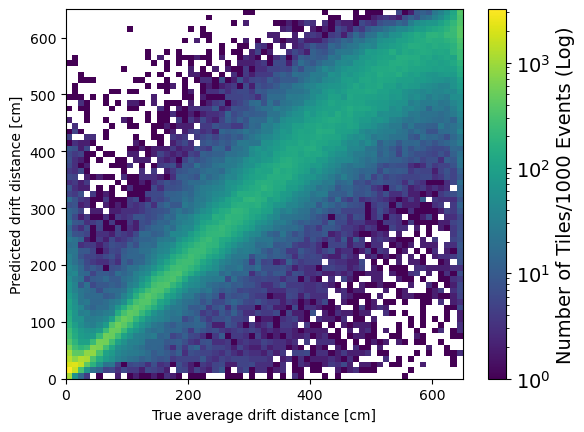

In [13]:
fig, ax = plt.subplots()
plt.rcParams.update({"font.size": 14})

h = ax.hist2d(y_test, preds, bins = (65, 65), range = [[0, 650], [0, 650]], cmap = 'viridis', norm = colors.LogNorm())

ax.set_xlabel('True average drift distance [cm]')
ax.set_ylabel('Predicted drift distance [cm]')
ax.set_xlim([0, 650])
ax.set_ylim([0, 650])

cbar = fig.colorbar(h[3])
# cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)") 

### Entire sample

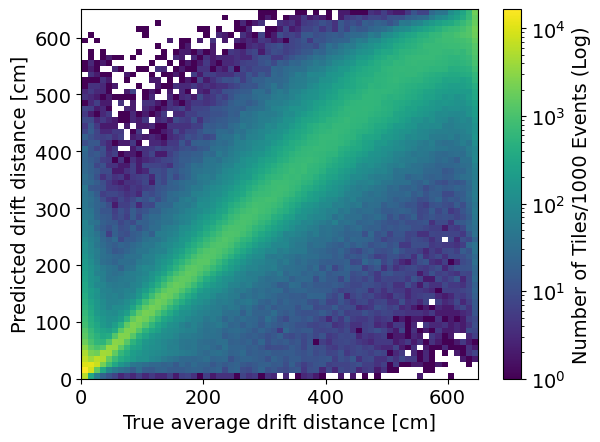

In [14]:
fig, ax = plt.subplots()
plt.rcParams.update({"font.size": 14})

h = ax.hist2d(df['drift_avg'], df['pred_drift'], bins = (65, 65), range = [[0, 650], [0, 650]], cmap = 'viridis', norm = colors.LogNorm())

ax.set_xlabel('True average drift distance [cm]')
ax.set_ylabel('Predicted drift distance [cm]')
ax.set_xlim([0, 650])
ax.set_ylim([0, 650])

cbar = fig.colorbar(h[3])
# cbar.ax.tick_params( labelsize = fonts)     # ticks (numbers)
cbar.set_label("Number of Tiles/1000 Events (Log)") 

In [16]:
len(preds)

148659

## Resolution

(-1.0, 1.0)

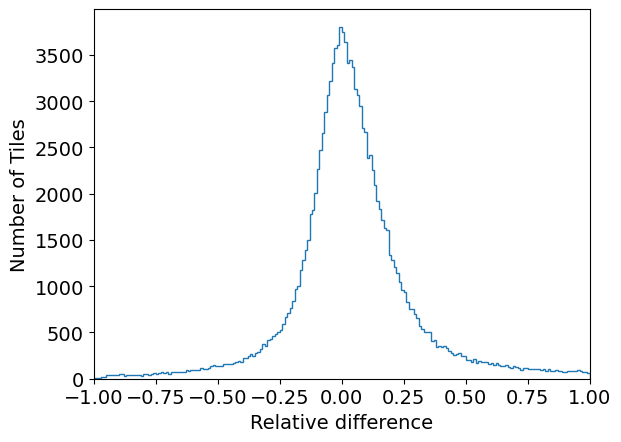

In [17]:
fig, ax = plt.subplots()
plt.rcParams.update({"font.size": 14})

ax.hist((preds - y_test)/y_test, bins = np.linspace(-1, 1, 201), histtype = 'step')

ax.set_xlabel('Relative difference')
ax.set_ylabel('Number of Tiles')
ax.set_xlim([-1, 1])

In [18]:
import seaborn as sns

In [19]:
df["drift_avg"].min(), df["drift_avg"].max()

(-0.03778076, 650.05237)

In [20]:
# example: df has columns 'drift_avg' and 'pred_drift'

# residual / difference
df["drift_diff"] = df["pred_drift"] - df["drift_avg"]

# make 25 cm bins for drift_avg
bin_width = 25
bins = np.arange(0, 675, bin_width)

df["drift_bin"] = pd.cut(df["drift_avg"], bins = bins, right = False)

In [21]:
df["drift_bin_label"] = df["drift_bin"].apply(lambda x: f"{int(x.left)}–{int(x.right)}")

Text(0, 0.5, 'Predicted - True drift distance [cm]')

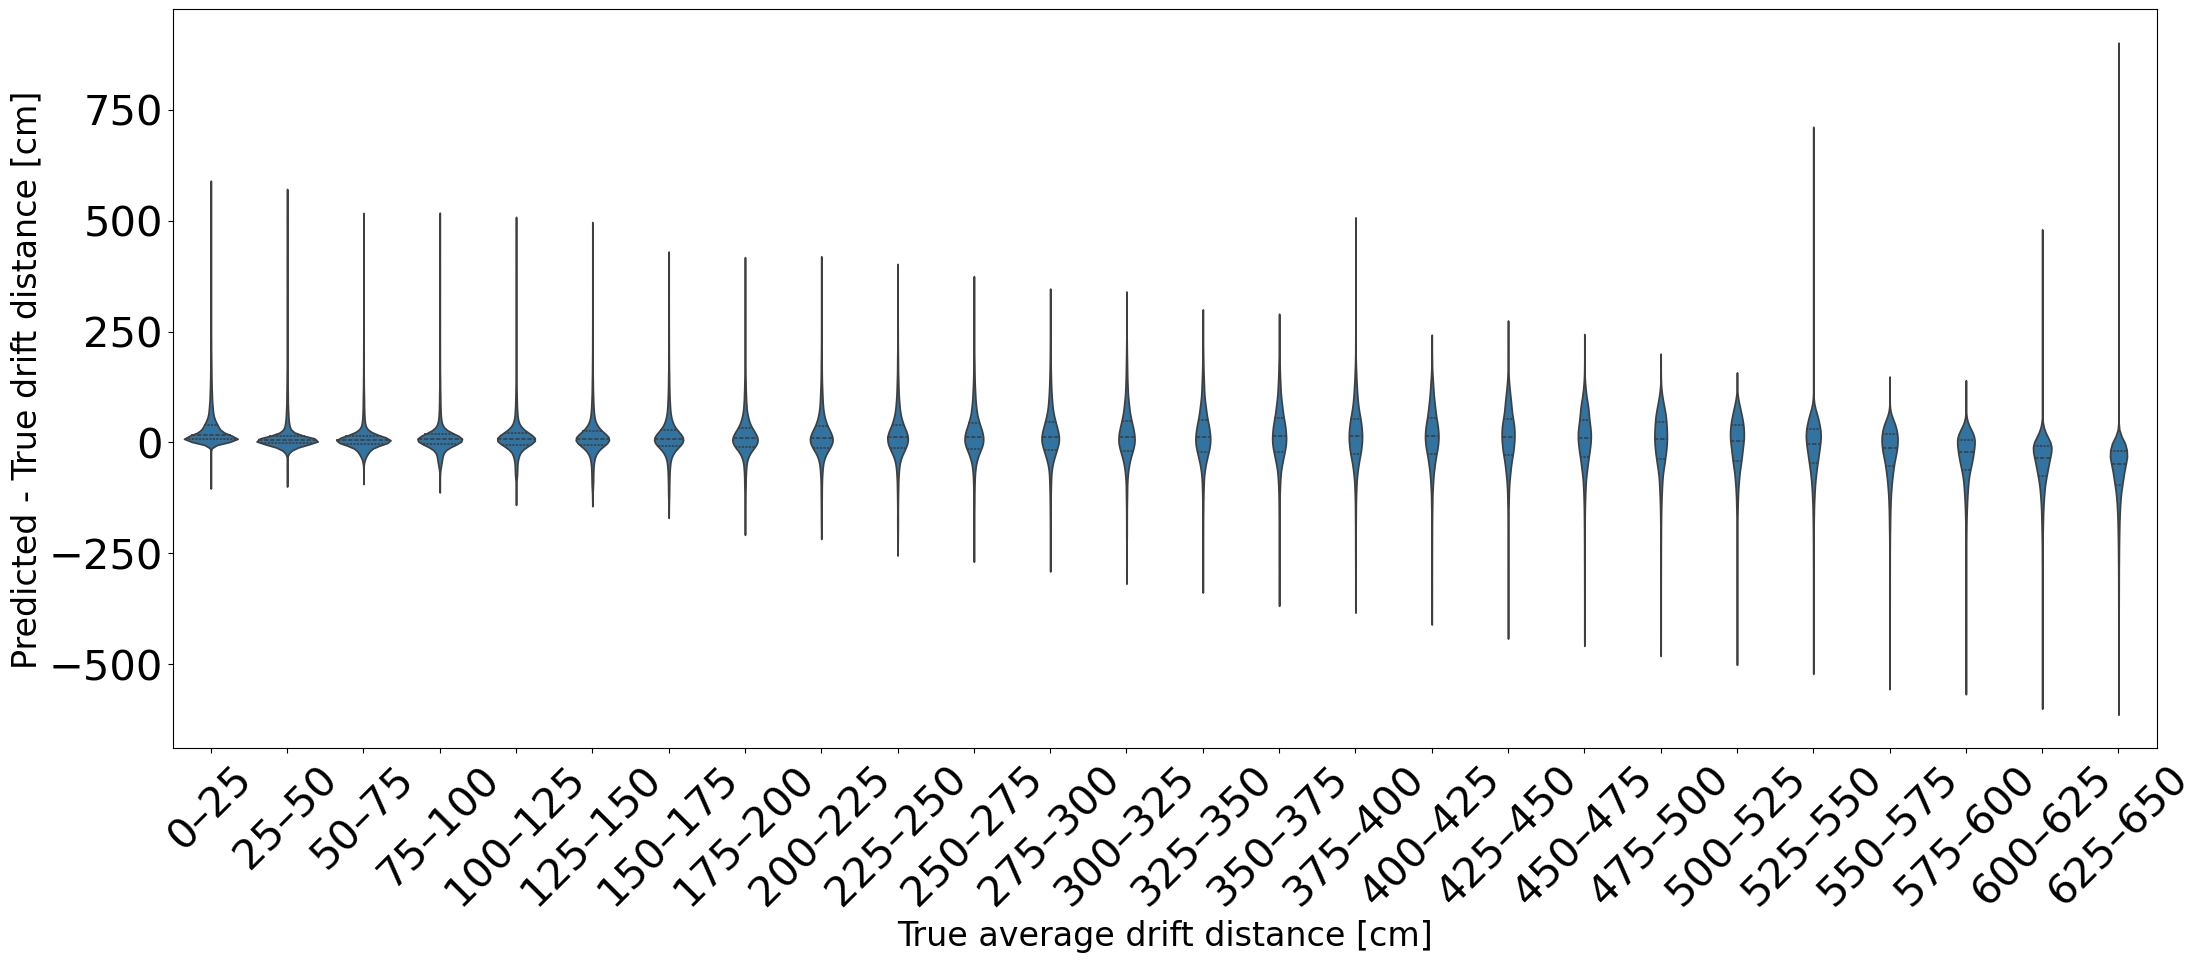

In [23]:
plt.rcParams.update({"font.size": 24,
                     "axes.labelsize": 24,
                     "xtick.labelsize": 30,
                     "ytick.labelsize": 30,})

fig, ax = plt.subplots(figsize = (25.6, 9.6))

sns.violinplot(data = df, x = "drift_bin_label", y = "drift_diff", inner = "quartile", cut = 0)

ax.tick_params(axis = 'x', labelrotation = 45)
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Predicted - True drift distance [cm]")

In [24]:
summary = (
    df.groupby("drift_bin")["drift_diff"]
    .quantile([0.16, 0.50, 0.84])
    .unstack()
    .rename(columns = {0.16: "q16", 0.50: "q50", 0.84: "q84"})
    .reset_index()
)

summary["drift_bin_center"] = summary["drift_bin"].apply(lambda b: (b.left + b.right) / 2)
summary["err_low"] = summary["q50"] - summary["q16"]
summary["err_high"] = summary["q84"] - summary["q50"]

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_15786/1822938074.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("drift_bin")["drift_diff"]


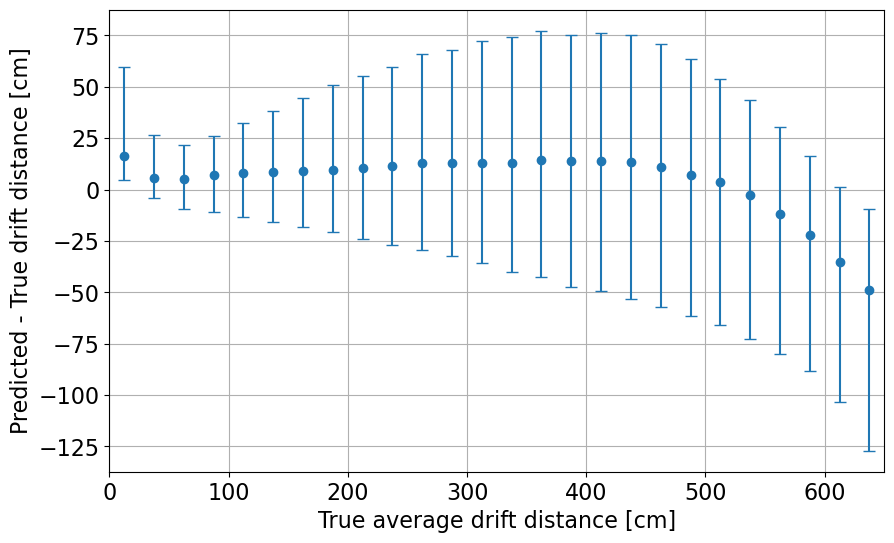

In [25]:
plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 16,
                     "xtick.labelsize": 16,
                     "ytick.labelsize": 16,})

fig, ax = plt.subplots(figsize = (10, 6))

ax.errorbar(
    summary["drift_bin_center"],
    summary["q50"],
    yerr = [summary["err_low"], summary["err_high"]],
    fmt = 'o',
    capsize = 4
)
ax.set_xlabel("True average drift distance [cm]")
ax.set_ylabel("Predicted - True drift distance [cm]")
ax.grid()
ax.set_xlim([0, 650])
plt.show()

In [26]:
def plot_drift_performance(
    df,
    truth_col = "drift_avg",
    pred_col = "pred_drift",
    bin_width = 25,
    min_entries = 1,
    figsize_violin = (12, 6),
    figsize_summary = (8, 5),
    min_val = 0,
    max_val = 650
):
    """
    Make violin, bias, resolution, relative bias, and relative resolution plots.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe containing truth and prediction columns.
    truth_col : str
        Column name for true/reference value.
    pred_col : str
        Column name for predicted value.
    bin_width : float
        Width of truth bins, e.g. 20 for 20 cm bins.
    min_entries : int
        Minimum number of entries required in a bin to keep it.
    figsize_violin : tuple
        Figure size for violin plot.
    figsize_summary : tuple
        Figure size for summary plots.

    Returns
    -------
    work_df : pandas.DataFrame
        Copy of input dataframe with derived columns.
    summary : pandas.DataFrame
        Summary table with quantiles and derived metrics.
    """

    work_df = df.copy()

    # keep only finite values
    work_df = work_df[np.isfinite(work_df[truth_col]) & np.isfinite(work_df[pred_col])].copy()

    # derived columns
    work_df["diff"] = work_df[pred_col] - work_df[truth_col]

    # for relative quantities avoid division by zero
    work_df["rel_diff"] = np.nan
    nonzero = work_df[truth_col] != 0
    work_df.loc[nonzero, "rel_diff"] = (
        work_df.loc[nonzero, "diff"] / work_df.loc[nonzero, truth_col]
    )

    # define bins
    # min_val = np.floor(work_df[truth_col].min() / bin_width) * bin_width
    # max_val = np.ceil(work_df[truth_col].max() / bin_width) * bin_width
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    work_df["drift_bin"] = pd.cut(work_df[truth_col], bins = bins, right = False)

    # remove empty / too-small bins
    counts = work_df["drift_bin"].value_counts().sort_index()
    valid_bins = counts[counts >= min_entries].index
    work_df = work_df[work_df["drift_bin"].isin(valid_bins)].copy()

    # ordered labels for plotting
    work_df["drift_bin_label"] = work_df["drift_bin"].apply(
        lambda x: f"[{int(x.left)}, {int(x.right)})"
    )

    # absolute summary
    abs_summary = (
        work_df.groupby("drift_bin")["diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "diff_q16", 0.50: "diff_q50", 0.84: "diff_q84"})
    )

    # relative summary
    rel_summary = (
        work_df.dropna(subset = ["rel_diff"])
        .groupby("drift_bin")["rel_diff"]
        .quantile([0.16, 0.50, 0.84])
        .unstack()
        .rename(columns = {0.16: "rel_q16", 0.50: "rel_q50", 0.84: "rel_q84"})
    )

    # counts and x positions
    count_summary = work_df.groupby("drift_bin").size().to_frame("count")

    summary = abs_summary.join(rel_summary, how = "left").join(count_summary, how = "left").reset_index()

    summary["x_center"] = summary["drift_bin"].apply(lambda b: (b.left + b.right) / 2)
    summary["bin_label"] = summary["drift_bin"].apply(lambda b: f"[{int(b.left)}, {int(b.right)})")

    # absolute bias/resolution
    summary["bias"] = summary["diff_q50"]
    summary["bias_err_low"] = summary["diff_q50"] - summary["diff_q16"]
    summary["bias_err_high"] = summary["diff_q84"] - summary["diff_q50"]
    summary["resolution"] = (summary["diff_q84"] - summary["diff_q16"]) / 2.0

    # relative bias/resolution
    summary["rel_bias"] = summary["rel_q50"]
    summary["rel_bias_err_low"] = summary["rel_q50"] - summary["rel_q16"]
    summary["rel_bias_err_high"] = summary["rel_q84"] - summary["rel_q50"]
    summary["rel_resolution"] = (summary["rel_q84"] - summary["rel_q16"]) / 2.0


    # Plot parameters
    plt.rcParams.update({"font.size": 16,
                     "axes.labelsize": 16,
                     "xtick.labelsize": 16,
                     "ytick.labelsize": 16,})

    # --------------------
    # 1. Violin plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_violin)
    
    sns.violinplot(
        data = work_df,
        x = "drift_bin_label",
        y = "diff",
        inner = "quartile",
        cut = 0,
        ax = ax
    )
    ax.set_xlabel(f"True average drift distance [cm]")
    ax.set_ylabel(f"Predicted - True drift distance [cm]")
    # ax.set_title("Distribution of prediction residuals by truth bin")
    ax.tick_params(axis = "x", labelrotation = 45)
    plt.tight_layout()
    plt.show()

    # --------------------
    # 2. Bias plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.errorbar(
        summary["x_center"],
        summary["bias"],
        yerr = [summary["bias_err_low"], summary["bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("Median of the Difference [cm]")
    ax.set_title("Prediction bias")
    ax.set_xlim([0, 650])
    ax.grid()
    
    plt.tight_layout()
    plt.show()

    # --------------------
    # 3. Resolution plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.plot(summary["x_center"], summary["resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the Difference [cm]")
    ax.set_title("Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.grid()

    plt.tight_layout()
    plt.show()

    # --------------------
    # 4. Relative bias plot
    # --------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.errorbar(
        summary["x_center"],
        summary["rel_bias"],
        yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel(f"Median of the relative difference")
    ax.set_title("Relative Bias vs truth")
    ax.set_xlim([0, 650])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # 5. Relative resolution plot
    # ---------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the relative difference")
    ax.set_title("Relative Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------
    # 6. Relative bias plot - y range [-0.2, 1]
    # --------------------------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.errorbar(
        summary["x_center"],
        summary["rel_bias"],
        yerr = [summary["rel_bias_err_low"], summary["rel_bias_err_high"]],
        fmt = "o-",
        capsize = 4
    )
    ax.axhline(0, color = "gray", linestyle = "--")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel(f"Median of the relative difference")
    ax.set_title("Relative Bias vs truth")
    ax.set_xlim([0, 650])
    ax.set_ylim([-0.3, 1])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # 7. Relative resolution plot - y range [0, 1]
    # --------------------------------------------------
    fig, ax = plt.subplots(figsize = figsize_summary)
    
    ax.plot(summary["x_center"], summary["rel_resolution"], "o-")
    ax.set_xlabel("True average drift distance [cm]")
    ax.set_ylabel("(q84 - q16)/2 of the relative difference")
    ax.set_title("Relative Resolution vs truth")
    ax.set_xlim([0, 650])
    ax.set_ylim([0, 1])
    ax.grid()
    # ax.set_yscale('log')
    plt.tight_layout()
    plt.show()

    return work_df, summary

/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_15786/3420932841.py:74: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  work_df.groupby("drift_bin")["diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_15786/3420932841.py:83: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("drift_bin")["rel_diff"]
/var/folders/bn/24gl1c290ls54cq54cz7rt9sfm8jyc/T/ipykernel_15786/3420932841.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

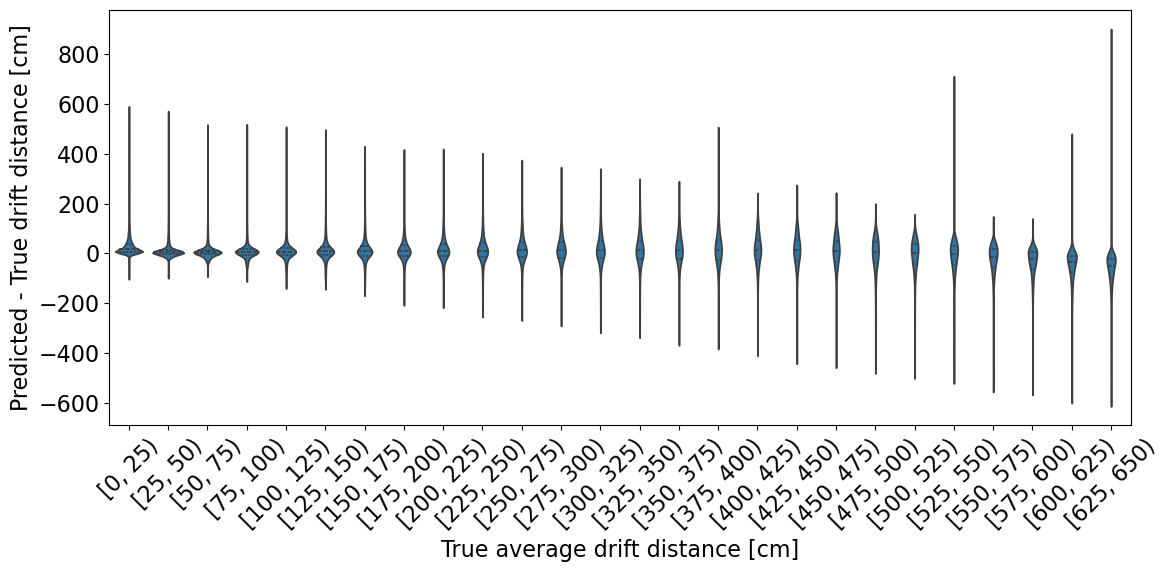

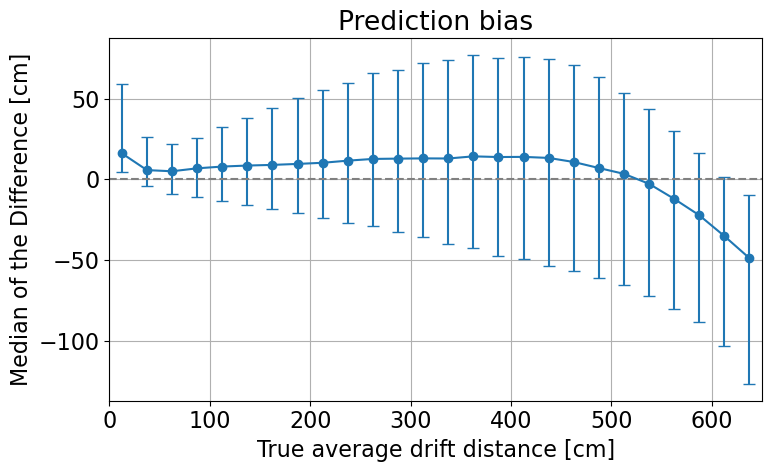

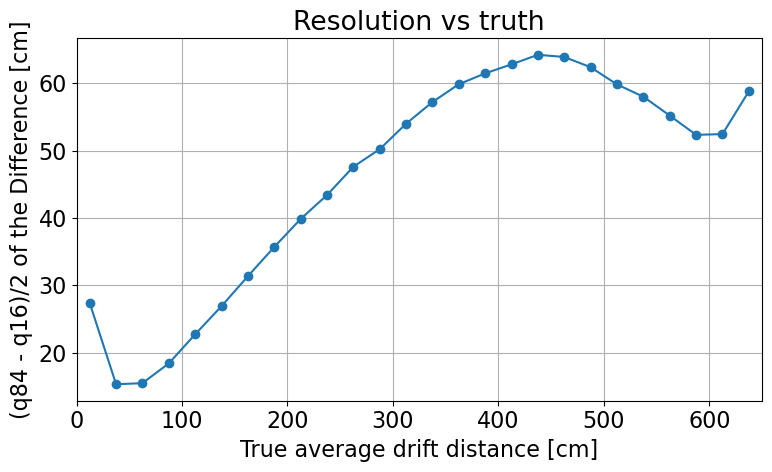

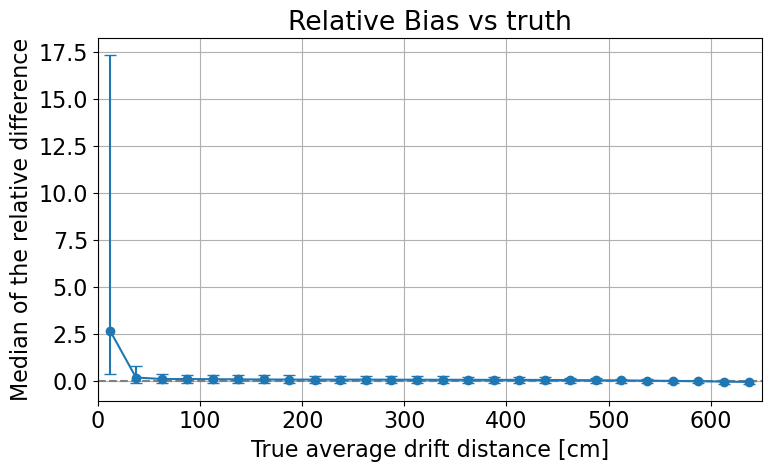

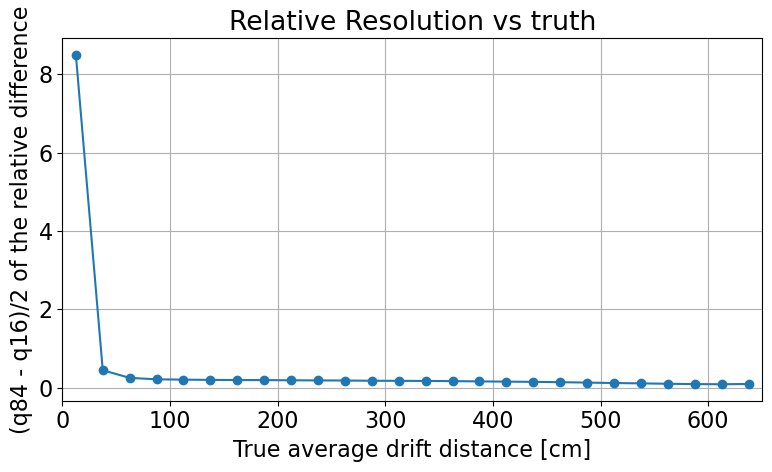

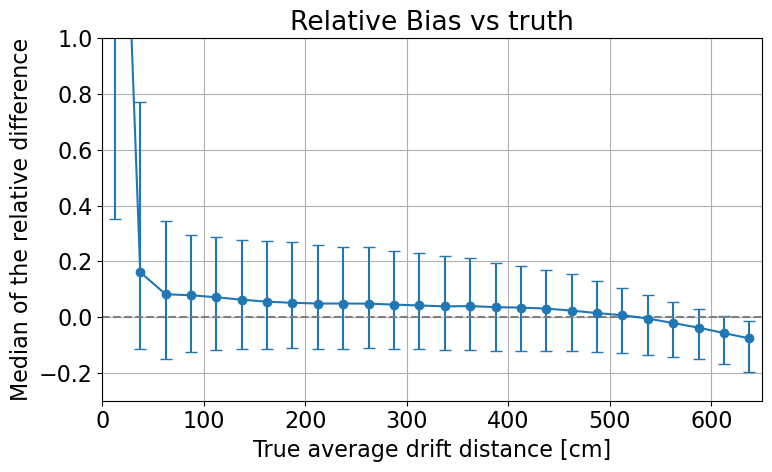

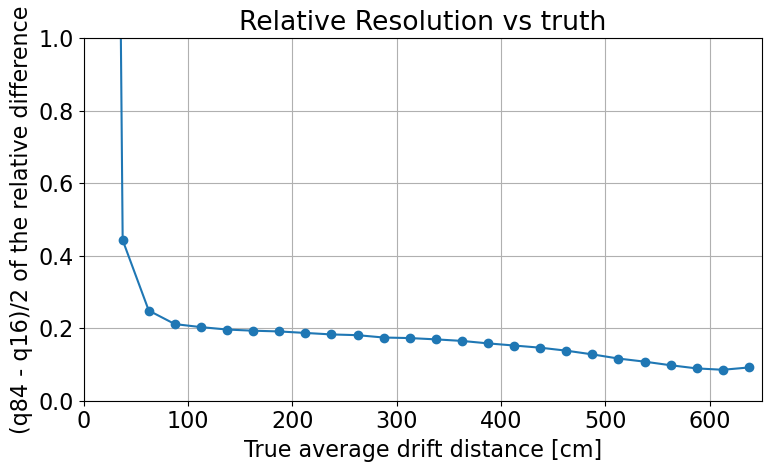

In [27]:
work_df, summary = plot_drift_performance(
    df,
    truth_col = "drift_avg",
    pred_col = "pred_drift",
    bin_width = 25
)